In [1]:
import mne
from pathlib import Path

In [2]:
path_to_dir = Path("/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw")
eeg_file = "sub-EMOP0004_ses-ieeg1_task-language_acq-4_run-1_ieeg.edf"
path_to_eeg = path_to_dir/eeg_file

In [3]:
raw = mne.io.read_raw_edf(path_to_eeg, preload=True)

Extracting EDF parameters from /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/sub-EMOP0004_ses-ieeg1_task-language_acq-4_run-1_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 11150015  =      0.000 ...  5444.343 secs...


/tmp/ipykernel_3003963/1845282016.py:1: RuntimeWarning: Omitted 6 annotation(s) that were outside data range.
  raw = mne.io.read_raw_edf(path_to_eeg, preload=True)


In [4]:
raw_data = raw.get_data()
raw_data.shape

(276, 11150016)

In [5]:
raw.ch_names

['LAm1',
 'LAm2',
 'LAm3',
 'LAm4',
 'LAm5',
 'LAm6',
 'LAm7',
 'LAm8',
 'LAm9',
 'LAm10',
 'LAm11',
 'LAm12',
 'LAm13',
 'LAHc1',
 'LAHc2',
 'LAHc3',
 'LAHc4',
 'LAHc5',
 'LAHc6',
 'LAHc7',
 'LAHc8',
 'LAHc9',
 'LAHc10',
 'LAHc11',
 'LAHc12',
 'LAHc13',
 'LMiHc1',
 'LMiHc2',
 'LMiHc3',
 'LMiHc4',
 'LMiHc5',
 'LMiHc6',
 'LMiHc7',
 'LMiHc8',
 'LMiHc9',
 'LMiHc10',
 'LMiHc11',
 'LMiHc12',
 'LTePo1',
 'LTePo2',
 'LTePo3',
 'LTePo4',
 'LTePo5',
 'LTePo6',
 'LTePo7',
 'LTePo8',
 'LTePo9',
 'LTePo10',
 'LTePo11',
 'LTePo12',
 'LTePo13',
 'LTePo14',
 'LEc1',
 'LEc2',
 'LEc3',
 'LEc4',
 'LEc5',
 'LEc6',
 'LEc7',
 'LEc8',
 'LPHG1',
 'LPHG2',
 'LPHG3',
 'LPHG4',
 'LPHG5',
 'LPHG6',
 'LPHG7',
 'LPHG8',
 'LPHG9',
 'LPHG10',
 'LPHG11',
 'LPHG12',
 'LMiIn1',
 'LMiIn2',
 'LMiIn3',
 'LMiIn4',
 'LMiIn5',
 'LMiIn6',
 'LMiIn7',
 'LMiIn8',
 'LMiIn9',
 'LMiIn10',
 'LMiIn11',
 'LMiIn12',
 'LMiIn13',
 'LMiIn14',
 'LMiIn15',
 'LMiIn16',
 'LPul1',
 'LPul2',
 'LPul3',
 'LPul4',
 'LPul5',
 'LPul6',
 'LPul7',
 'L

In [6]:
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: LAm1, LAm2, LAm3, LAm4, LAm5, LAm6, LAm7, LAm8, LAm9, LAm10, ...
 chs: 276 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 1024.0 Hz
 meas_date: 2001-06-24 15:35:53 UTC
 nchan: 276
 projs: []
 sfreq: 2048.0 Hz
 subject_info: <subject_info | his_id: sub-EMOP0004, sex: 0, last_name: X>
>

In [7]:
import re
ch_names = raw.ch_names
ch_IDs = sorted(set(re.sub(r'\d+$', '', ch) for ch in ch_names))
print(ch_IDs)
lh_channels = [ch for ch in ch_IDs if ch[0].lower() == "l"]
rh_channels = [ch for ch in ch_IDs if ch[0].lower() == "r"]
eeg_ch_set = lh_channels + rh_channels

import re

eeg_channels= [ch for ch in ch_names if re.sub(r'\d+$', '', ch) in eeg_ch_set]

['DC', 'EKG', 'LAHc', 'LAIn', 'LAm', 'LEc', 'LMiHc', 'LMiIn', 'LOFc', 'LPHG', 'LPul', 'LTePo', 'OSAT', 'PR', 'Pleth', 'RAHc', 'RAIn', 'RANT', 'RAm', 'REc', 'RMiHc', 'ROFc', 'RPHG', 'RPuI', 'RTePo', 'TRIG']


In [8]:
raw.set_channel_types({ch:"seeg" for ch in eeg_channels})
print(raw.get_channel_types(picks=250))

['seeg']


## Spectral Analysis

Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_3003963/1133552909.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd.plot()


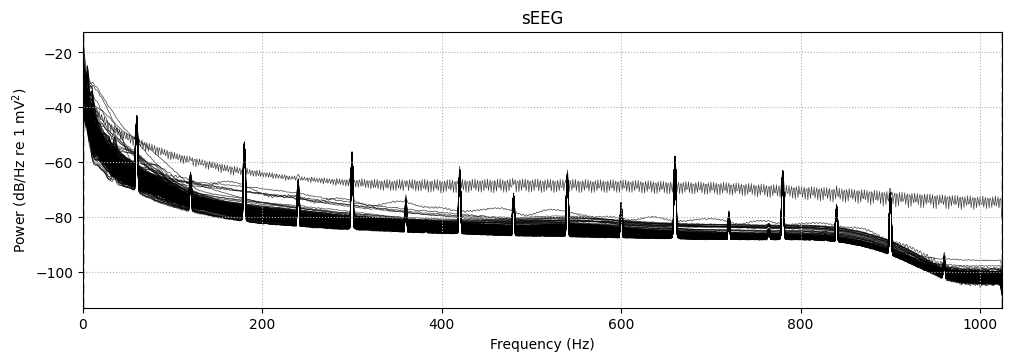

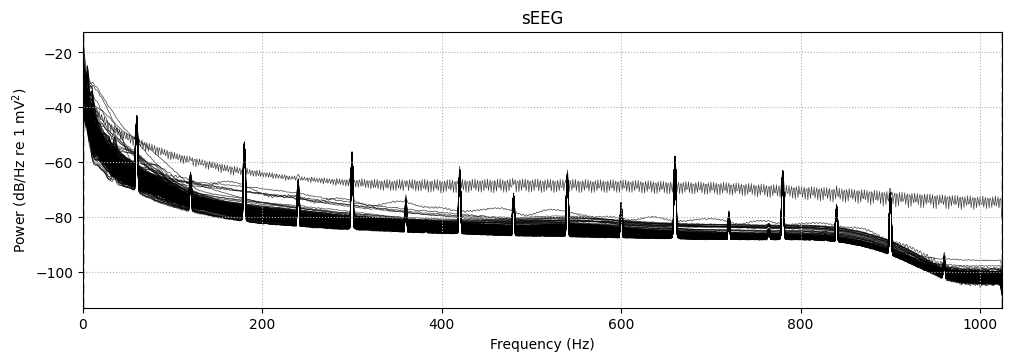

In [9]:
psd = raw.compute_psd(picks="seeg")
psd.plot()

In [10]:
psd_data = psd.get_data()   # shape: (n_channels, n_freqs)
freqs = psd.freqs
ch_names = psd.ch_names

In [11]:
import numpy as np
import matplotlib.pyplot as plt


corr_matrix = np.corrcoef(psd_data)



In [12]:
corr_matrix[0:5,0:5]

array([[1.        , 0.99514569, 0.98934144, 0.98558992, 0.98297876],
       [0.99514569, 1.        , 0.99856671, 0.99616337, 0.99414243],
       [0.98934144, 0.99856671, 1.        , 0.99913567, 0.99803526],
       [0.98558992, 0.99616337, 0.99913567, 1.        , 0.99921301],
       [0.98297876, 0.99414243, 0.99803526, 0.99921301, 1.        ]])

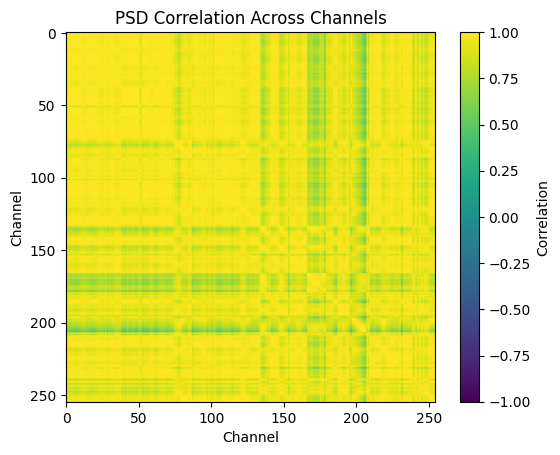

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure()
plt.imshow(corr_matrix, cmap="viridis", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("PSD Correlation Across Channels")
plt.xlabel("Channel")
plt.ylabel("Channel")
plt.show()

In [14]:
# corr_matrix shape: (n_channels, n_channels)
n = corr_matrix.shape[0]

# Remove diagonal by setting it to NaN
corr_no_diag = corr_matrix.copy()
np.fill_diagonal(corr_no_diag, np.nan)

# Mean correlation per channel (ignoring diagonal)
mean_corr = np.nanmean(corr_no_diag, axis=1)

# Sort channels by mean correlation
sorted_indices = np.argsort(mean_corr)

# Sorted mean correlations
sorted_mean_corr = mean_corr[sorted_indices]

# If you have channel names
sorted_channels = [ch_names[i] for i in sorted_indices]

# Output
for idx, ch, val in zip(sorted_indices, sorted_channels, sorted_mean_corr):
    print(idx, ch, val)

206 RANT10 0.656043019224573
205 RANT9 0.6833621050020012
178 REc3 0.7191567669799421
204 RANT8 0.74516446140847
173 RTePo8 0.7806207820390086
171 RTePo6 0.7827353700466179
170 RTePo5 0.7969441717476301
203 RANT7 0.801421801560544
172 RTePo7 0.8039871188378325
167 RTePo2 0.8142567992546785
135 RAm9 0.8222563933403222
168 RTePo3 0.8260144175791471
174 RTePo9 0.8342431237646907
202 RANT6 0.8343521601916526
136 RAm10 0.8447174411059911
239 ROFc11 0.8449582722513674
166 RTePo1 0.8508742536750232
201 RANT5 0.8571335560734201
153 RAHc13 0.8620136381342975
177 REc2 0.8640477791872822
242 ROFc14 0.8673318118837025
231 ROFc3 0.8676222870583907
169 RTePo4 0.8683849685625874
176 REc1 0.8684558844532683
200 RANT4 0.8699884292230348
195 RPHG12 0.8778714448655295
77 LMiIn6 0.878150181884984
245 RAIn3 0.8786639083752363
134 RAm8 0.8793714154823636
196 RPHG13 0.8822285151095224
199 RANT3 0.8828047843358057
208 RANT12 0.8832499574363607
148 RAHc8 0.8850438655234074
247 RAIn5 0.8859617721750107
137 RAm1

0.656043019224573


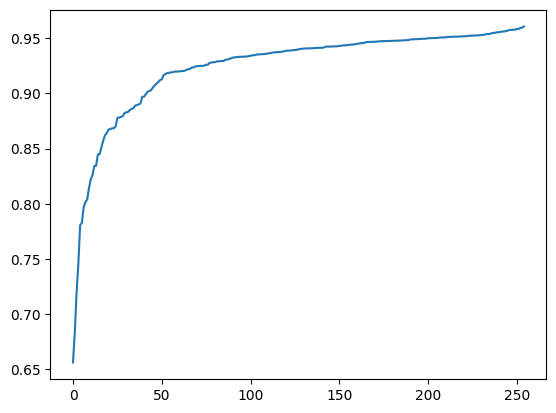

In [15]:
plt.plot(sorted_mean_corr)
print(sorted_mean_corr[0])

Plotting power spectral density (dB=True).
ROFc3


/tmp/ipykernel_3003963/829530106.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd.plot(picks=sorted_indices[21:31]);


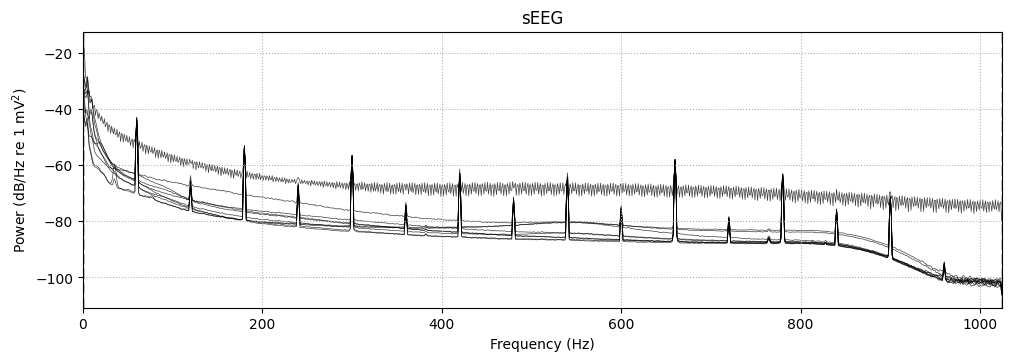

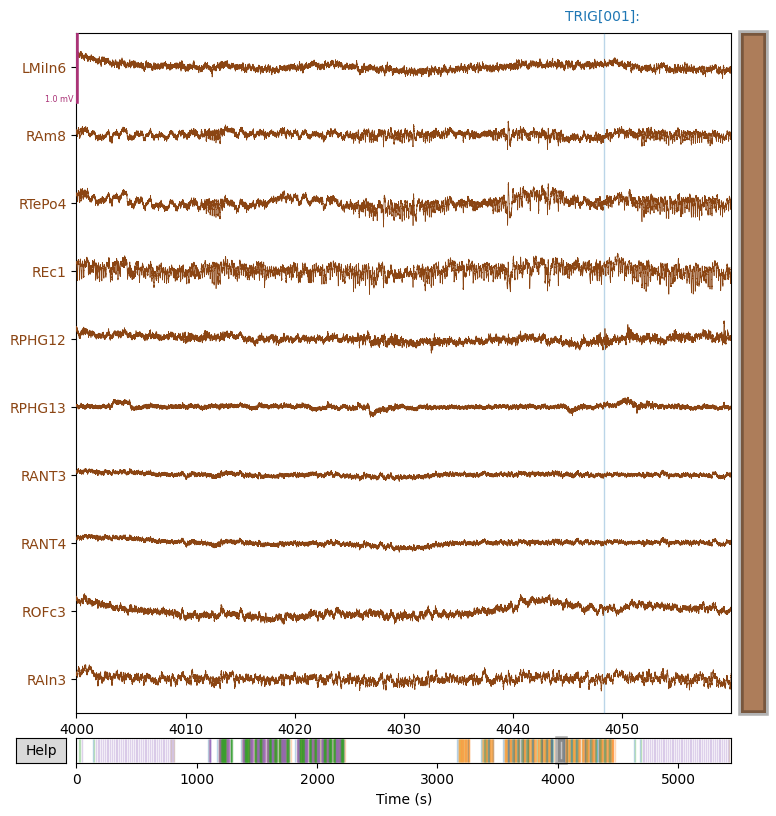

In [34]:
psd.plot(picks=sorted_indices[21:31]);
print(sorted_channels[21])
raw.plot( picks= sorted_channels[21:31],
    duration=60,   # seconds shown at once
    start=4000,       # start time in seconds
    n_channels=10,  # how many stacked traces
    scalings={"seeg": 500e-6})
print()

In [83]:
Y = psd_data
n_ch, n_f = Y.shape

# SSE for all pairs: sum_k (y_i[k] - y_j[k])^2
# Use broadcasting to compute pairwise squared error efficiently.
diff = Y[:, None, :] - Y[None, :, :]              # (n_ch, n_ch, n_freqs)
sse = np.sum(diff * diff, axis=2)                  # (n_ch, n_ch)

# SST for each "target" channel i: sum_k (y_i[k] - mean(y_i))^2
y_mean = Y.mean(axis=1, keepdims=True)             # (n_ch, 1)
sst = np.sum((Y - y_mean) ** 2, axis=1)            # (n_ch,)

# R^2_pred(target i <- predictor j): 1 - SSE(i,j)/SST(i)
# Broadcast SST across columns (predictors)
r2_pred = 1.0 - sse / sst[:, None]                 # (n_ch, n_ch)

# Optional: diagonal is perfect (channel predicts itself)
np.fill_diagonal(r2_pred, 1.0)

In [85]:
r2_pred

array([[ 1.00000000e+00,  9.81037851e-01,  8.37116959e-01, ...,
         6.89456912e-02,  6.99700057e-02,  8.36726087e-02],
       [ 9.76587785e-01,  1.00000000e+00,  8.96968850e-01, ...,
         7.76822275e-02,  7.88637583e-02,  9.42234355e-02],
       [ 5.68710581e-01,  7.79043625e-01,  1.00000000e+00, ...,
         1.14721060e-01,  1.16451445e-01,  1.38589425e-01],
       ...,
       [-5.68169396e+02, -4.55659141e+02, -2.03387214e+02, ...,
         1.00000000e+00,  9.99646937e-01,  9.60780281e-01],
       [-5.53432883e+02, -4.43755110e+02, -1.97925066e+02, ...,
         9.99655700e-01,  1.00000000e+00,  9.67398059e-01],
       [-3.99477154e+02, -3.19621919e+02, -1.41181909e+02, ...,
         9.71960838e-01,  9.76098866e-01,  1.00000000e+00]],
      shape=(255, 255))

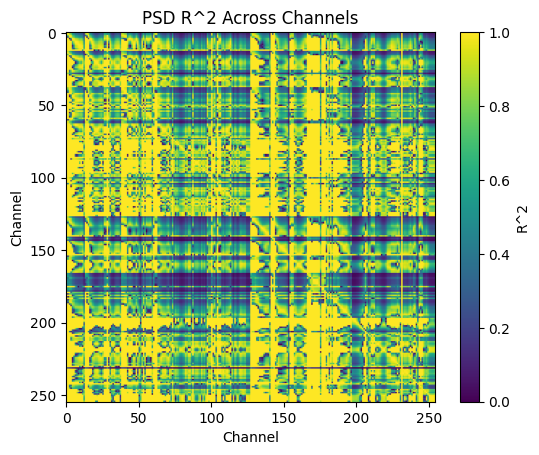

In [92]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure()
plt.imshow(np.abs(r2_pred), cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="R^2")
plt.title("PSD R^2 Across Channels")
plt.xlabel("Channel")
plt.ylabel("Channel")
plt.show()

In [93]:
# corr_matrix shape: (n_channels, n_channels)
n = corr_matrix.shape[0]

# Remove diagonal by setting it to NaN
r2_no_diag = r2_pred.copy()
np.fill_diagonal(np.abs(r2_no_diag), np.nan)

# Mean correlation per channel (ignoring diagonal)
mean_r2 = np.nanmean(r2_no_diag, axis=1)

# Sort channels by mean correlation
sorted_indices = np.argsort(mean_r2)

# Sorted mean correlations
sorted_mean_r2 = mean_r2[sorted_indices]

# If you have channel names
sorted_channels = [ch_names[i] for i in sorted_indices]

# Output
for idx, ch, val in zip(sorted_indices, sorted_channels, sorted_mean_corr):
    print(idx, ch, val)

198 RANT2 0.656043019224573
199 RANT3 0.6833621050020012
153 RAHc13 0.7191567669799421
197 RANT1 0.74516446140847
200 RANT4 0.7806207820390086
79 LMiIn8 0.7827353700466179
252 RAIn10 0.7969441717476301
201 RANT5 0.801421801560544
253 RAIn11 0.8039871188378325
251 RAIn9 0.8142567992546785
80 LMiIn9 0.8222563933403222
125 LAIn10 0.8260144175791471
242 ROFc14 0.8342431237646907
78 LMiIn7 0.8343521601916526
218 RPuI6 0.8447174411059911
96 LPul9 0.8449582722513674
219 RPuI7 0.8508742536750232
118 LAIn3 0.8571335560734201
124 LAIn9 0.8620136381342975
115 LOFc13 0.8640477791872822
250 RAIn8 0.8673318118837025
92 LPul5 0.8676222870583907
126 LAIn11 0.8683849685625874
254 RAIn12 0.8684558844532683
81 LMiIn10 0.8699884292230348
217 RPuI5 0.8778714448655295
86 LMiIn15 0.878150181884984
74 LMiIn3 0.8786639083752363
220 RPuI8 0.8793714154823636
94 LPul7 0.8822285151095224
51 LTePo14 0.8828047843358057
88 LPul1 0.8832499574363607
202 RANT6 0.8850438655234074
91 LPul4 0.8859617721750107
117 LAIn2 0.8

In [68]:
### Line noise estimate
idx60 = np.argmin(np.abs(freqs - 60))

line_power = psd_data[:, idx60]   # one value per channel
mean = line_power.mean()
std = line_power.std()
cutoff = mean + 5 * std

z = (line_power - mean) / std

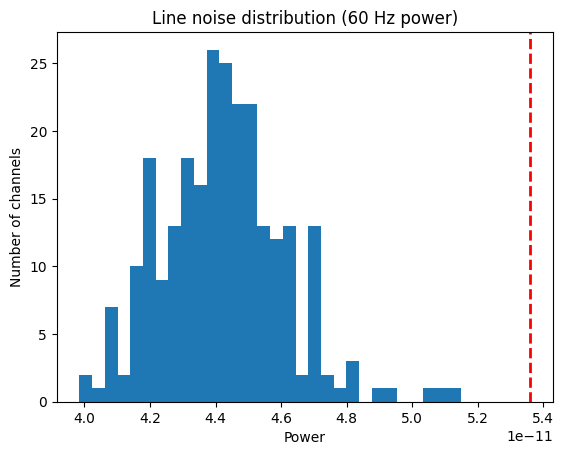

In [69]:
plt.hist(line_power, bins=30)
plt.axvline(cutoff, color="red", linestyle="--", linewidth=2, label="5 SD cutoff")
plt.title("Line noise distribution (60 Hz power)")
plt.xlabel("Power")
plt.ylabel("Number of channels")
plt.show()

## Filtering

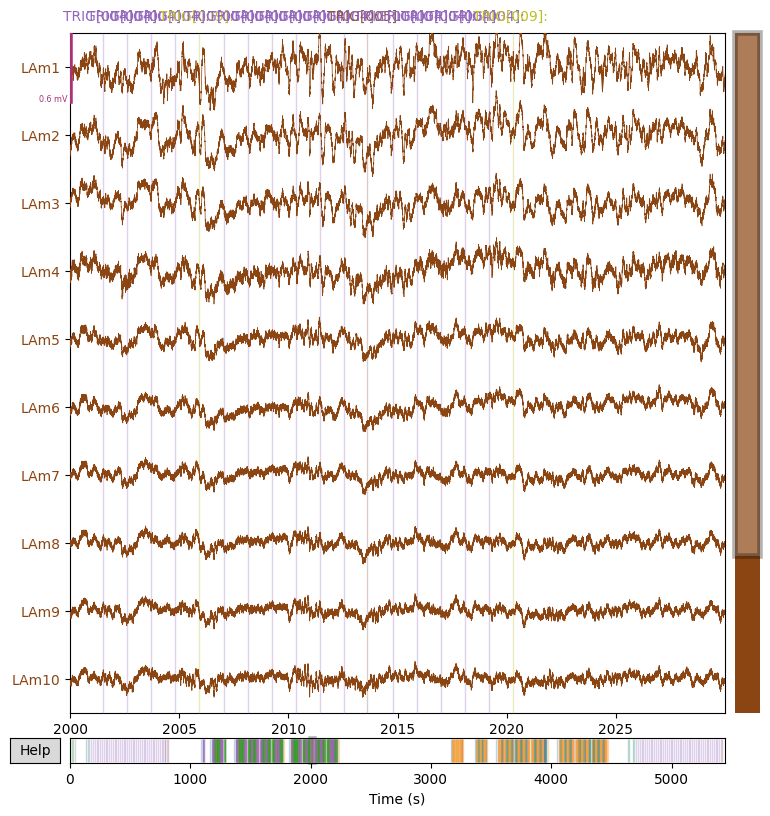

In [70]:
# before filtering
raw.plot(
    picks=eeg_channels[0:13],
    duration=30,   # seconds shown at once
    start=2000,       # start time in seconds
    n_channels=10,  # how many stacked traces
    scalings={"seeg": 300e-6}
);

High pass

In [71]:
#high pass filter of 0.5hz
raw.filter(l_freq=0.5, h_freq=None, picks="seeg",phase="zero")

Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.5 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Filter length: 13517 samples (6.600 s)



<RawEDF | sub-EMOP0004_ses-ieeg1_task-language_acq-4_run-1_ieeg.edf, 276 x 11150016 (5444.3 s), ~22.93 GiB, data loaded>

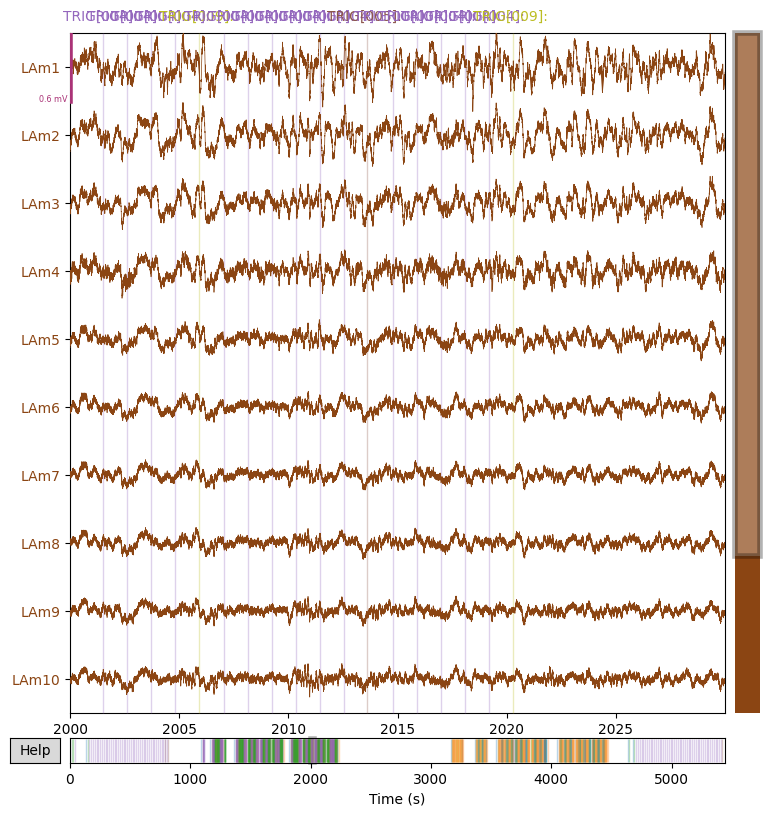

In [72]:
raw.plot(
    picks=eeg_channels[0:13],
    duration=30,   # seconds shown at once
    start=2000,       # start time in seconds
    n_channels=10,  # how many stacked traces
    scalings={"seeg": 300e-6}
);

Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_2923910/1133552909.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd.plot()


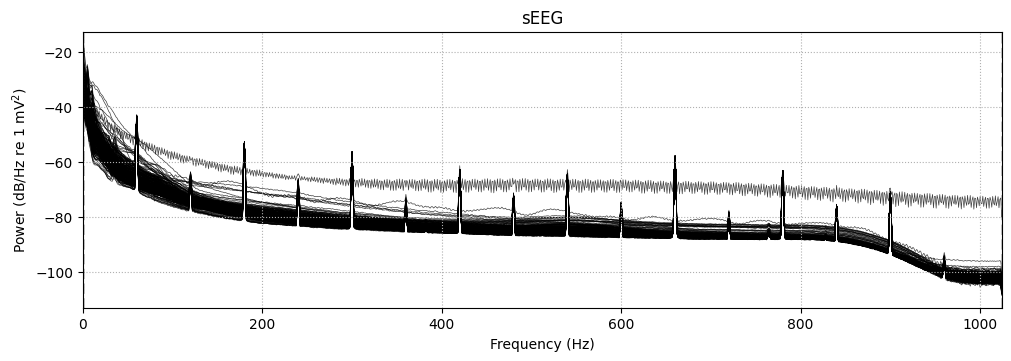

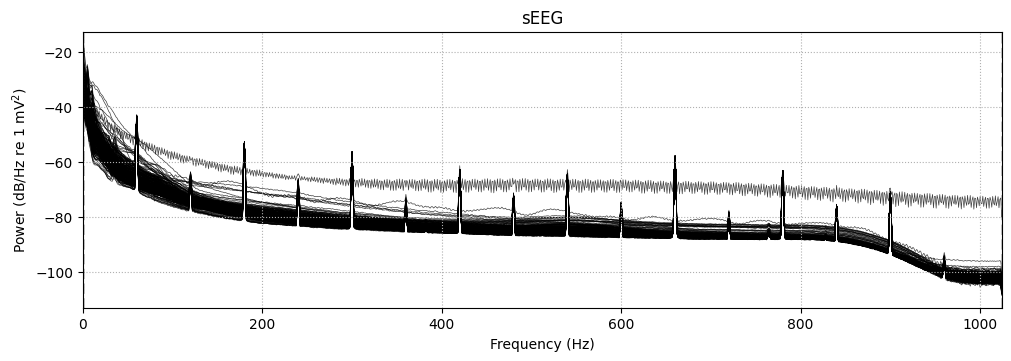

In [73]:
psd = raw.compute_psd(picks="seeg")
psd.plot();

Notch filter

In [74]:
freqs = [60,120,180,240]

for f in freqs:
    raw.notch_filter(
        freqs=f,
        method="iir",
        picks="seeg"
    )

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 59.35, 60.65 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 1.2e+02 - 1.2e+02 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 119.20, 120.80 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 1.8e+02 - 1.8e+02 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 179.05, 180.95 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contigu

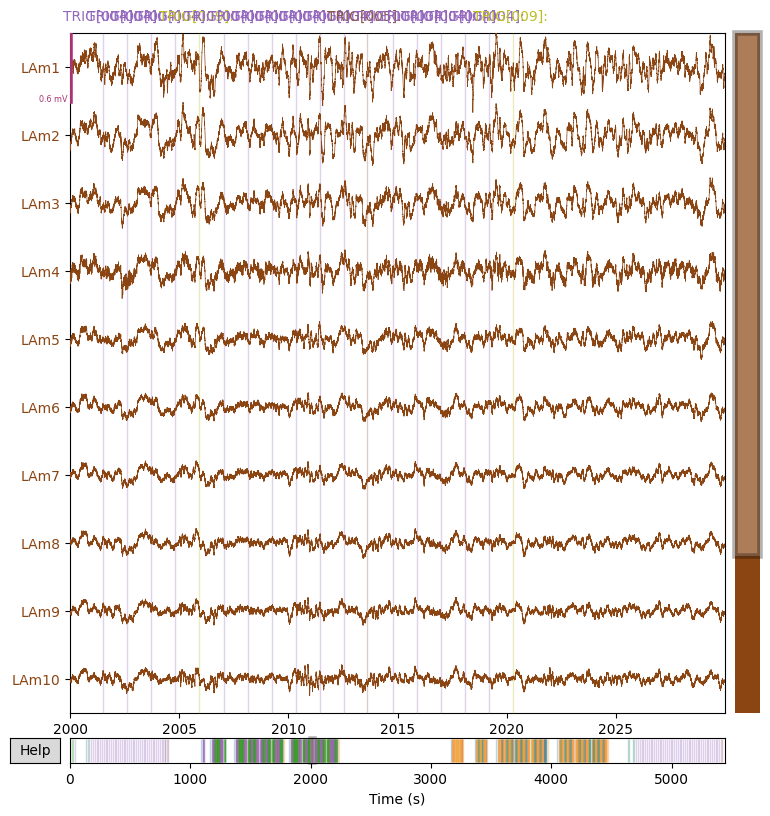

In [75]:
raw.plot(
    picks=eeg_channels[0:13],
    duration=30,   # seconds shown at once
    start=2000,       # start time in seconds
    n_channels=10,  # how many stacked traces
    scalings={"seeg": 300e-6}
);

Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_2923910/2332745581.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd.plot();


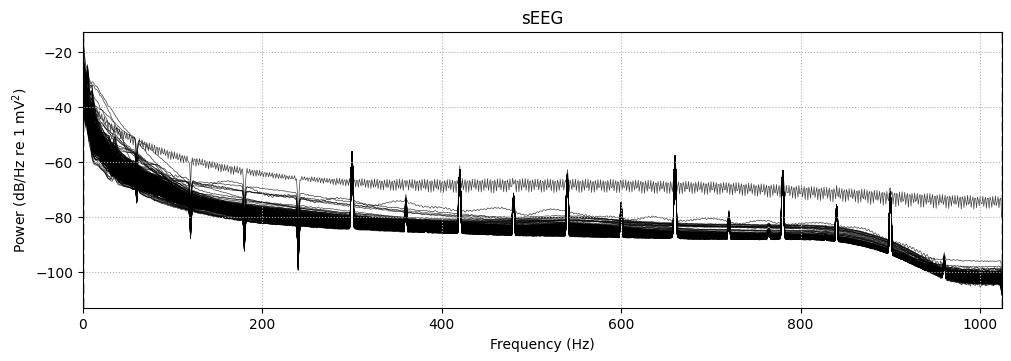

In [76]:
psd = raw.compute_psd(picks="seeg")
psd.plot();

In [78]:
raw.save(path_to_dir/"raw_preprocessed_1.fif", overwrite=True)

Writing /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1.fif


/tmp/ipykernel_2923910/1826159471.py:1: RuntimeWarning: This filename (/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(path_to_dir/"raw_preprocessed_1.fif", overwrite=True)


Closing /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1.fif
Writing /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1-1.fif
Closing /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1-1.fif
Writing /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1-2.fif
Closing /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1-2.fif
Writing /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1-3.fif
Closing /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1-3.fif
Writing /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1-4.fif
Closing /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1-4.fif
Writing /storage/cedar/cedar_c

[PosixPath('/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1.fif'),
 PosixPath('/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1-1.fif'),
 PosixPath('/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1-2.fif'),
 PosixPath('/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1-3.fif'),
 PosixPath('/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1-4.fif'),
 PosixPath('/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1-5.fif')]

# Part 2: Hilbert Transform


In [3]:
raw = mne.io.read_raw_fif(path_to_dir/"raw_preprocessed_1.fif", preload=True)

Opening raw data file /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1.fif...


/tmp/ipykernel_2862615/1860434879.py:1: RuntimeWarning: This filename (/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(path_to_dir/"raw_preprocessed_1.fif", preload=True)


Isotrak not found
    Range : 0 ... 1943551 =      0.000 ...   949.000 secs
Ready.
Opening raw data file /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1-1.fif...
Isotrak not found
    Range : 1943552 ... 3887103 =    949.000 ...  1898.000 secs
Ready.
Opening raw data file /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1-2.fif...
Isotrak not found
    Range : 3887104 ... 5830655 =   1898.000 ...  2847.000 secs
Ready.
Opening raw data file /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1-3.fif...
Isotrak not found
    Range : 5830656 ... 7774207 =   2847.000 ...  3796.000 secs
Ready.
Opening raw data file /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/raw_preprocessed_1-4.fif...
Isotrak not found
    Range : 7774208 ... 9717759 =   3796.000 ...  4745.000 secs
Ready.
Opening raw data file /storage/cedar/cedar_cos/cos-lab-aivano

Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_2862615/2332745581.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd.plot();


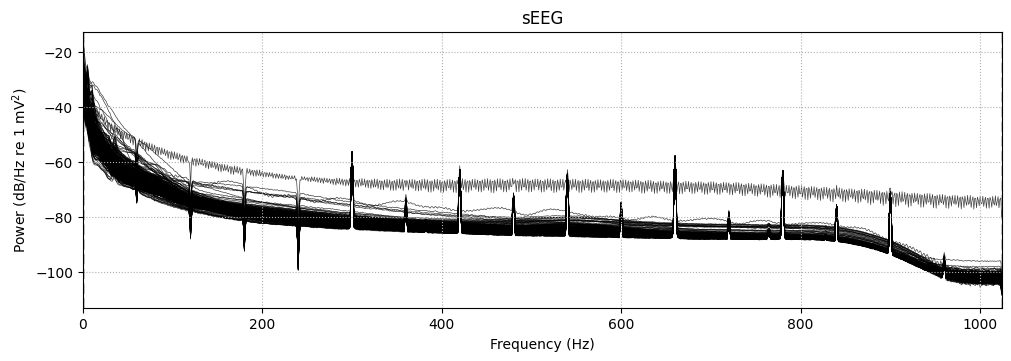

In [4]:
psd = raw.compute_psd(picks="seeg")
psd.plot();

Plotting power spectral density (dB=True).


/tmp/ipykernel_2862615/1643921219.py:9: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd_subset.plot()


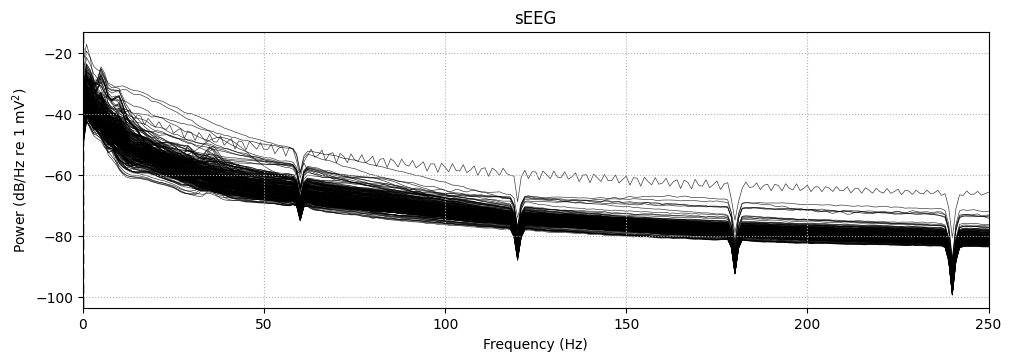

In [7]:
import numpy as np

mask = psd.freqs <= 250
psd_subset = psd.copy()

psd_subset._data = psd_subset._data[:, mask]
psd_subset._freqs = psd_subset._freqs[mask]

psd_subset.plot()